# Single Crystal Data Reduction workflow for MAGiC diffractometer
***(notebook version)***

This notebook presents skeleton of data reduction procedure for Single Crystal for McStas h5 file of MAGiC using SCIPP. The steps are described on the corresponding [confluence page](https://confluence.ess.eu/spaces/~iuriikibalin/pages/788704198/Single-Crystal+Data+Reduction+Workflow+for+MAGiC+with+Scipp+Tasks).

In [1]:
%matplotlib widget
import numpy 
import os
import scipy
import ipywidgets
from scipy.ndimage import label, center_of_mass, sum as ndi_sum
import scipp as sc
from scippneutron.conversion import graph
import matplotlib.pyplot as plt

import ipywidgets as widgets

import inspect
import plopp

import read_h5
import plot_data_ddict
import magic_graphs
import magic_scipp
import peak_find
import get_ub
import integrate_peaks
import operations_with_da


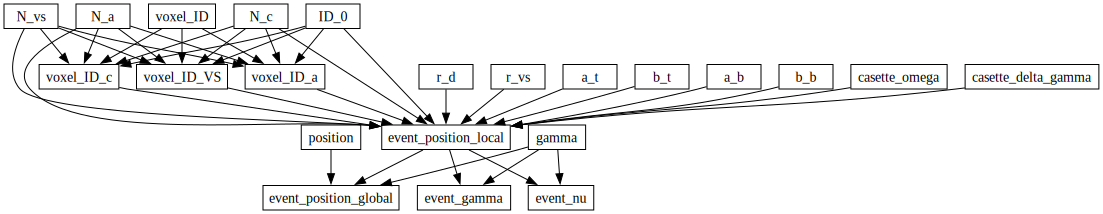

In [2]:
# sc.show_graph(magic_graphs.scipp_graph, simplified=True)
# sc.show_graph(magic_graphs.graph_qvec, simplified=True)
sc.show_graph(magic_graphs.graph_detector, simplified=True)
# sc.show_graph(magic_graphs.graph_hkl, simplified=True)
# sc.show_graph(magic_graphs.graph_hkl_inv, simplified=True)
# sc.show_graph(magic_graphs.graph_ub_inv, simplified=True)
# sc.show_graph(magic_graphs.graph_cave_monitor, simplified=True)


# Preprocessing

## Load Event Data

The data processing pipeline is currently designed for simulated data.  

Uncomment the cell below to run a McStas simulation using the provided [McStas model](https://git.esss.dk/dmsc-instrumentmodels/magic). This will take some time.

In [3]:
# !git clone https://git.esss.dk/dmsc-instrumentmodels/magic.git
# import os
# import sys
# sys.path.append(os.path.join(".","magic"))
# from run_simulation import  SimulationConfig, run_simulation
# sample = "Al_sg225.ncmat;dir1=@crys:0,0,1@lab:0,0,1;dir2=@crys:1,0,0@lab:1,0,0;temp=-100C"
# cfg = SimulationConfig(ncount=5e10, mpi=6, output_directory="run_folder", sample=sample)
# run_simulation(cfg)

The simulation file contains information about event data on the detector and information from the cave monitor

In [4]:
f_nexus_data = r"/Users/iuriikibalin/Downloads/sim_c60/mccode.h5"
dg_magic = read_h5.read_magic_from_nexus(f_nexus_data)
da_det_a = dg_magic['detector_a']
da_det_b = dg_magic['detector_b']

In [9]:
f_nexus_vanadium = r"/Users/iuriikibalin/Downloads/sim_vanadium/mccode.h5"
dg_magic_vanadium = read_h5.read_magic_from_nexus(f_nexus_vanadium)
da_det_a_vanadium = dg_magic_vanadium['detector_a']
da_det_b_vanadium = dg_magic_vanadium['detector_b']

In [10]:
da_det_a = da_det_a.transform_coords(("event_gamma",'event_nu', 'event_position_global'), graph=magic_graphs.graph_detector, rename_dims=False)
da_det_b = da_det_b.transform_coords(("event_gamma",'event_nu', 'event_position_global'), graph=magic_graphs.graph_detector, rename_dims=False)

In [11]:
da_det_a_vanadium = da_det_a_vanadium.transform_coords(("event_gamma",'event_nu', 'event_position_global'), graph=magic_graphs.graph_detector, rename_dims=False)
da_det_b_vanadium = da_det_b_vanadium.transform_coords(("event_gamma",'event_nu', 'event_position_global'), graph=magic_graphs.graph_detector, rename_dims=False)


In [12]:
# plopp.scatter3d({'Detector A':da_det_a,'Detector B':da_det_b,}, pos='event_position_local', cbar=True, size=0.03, opacity=0.5, perspective=False)


In [13]:
s_det_a = f'Number of events on detector A is 10^{numpy.log10(da_det_a.data.values.size).astype(int):}.'
s_det_b = f'Number of events on detector A is 10^{numpy.log10(da_det_b.data.values.size).astype(int):}.'
print(s_det_a)
print(s_det_b)

Number of events on detector A is 10^7.
Number of events on detector A is 10^5.


In [14]:
s_det_a_vanadium = f'Number of events on detector A is 10^{numpy.log10(da_det_a_vanadium.data.values.size).astype(int):}.'
s_det_b_vanadium = f'Number of events on detector A is 10^{numpy.log10(da_det_b_vanadium.data.values.size).astype(int):}.'
print(s_det_a_vanadium)
print(s_det_b_vanadium)

Number of events on detector A is 10^6.
Number of events on detector A is 10^6.


# Histogramming of data 
(in this case we solve the problem of long measurements when there is a lot of events)

In [15]:
import importlib
importlib.reload(operations_with_da)

<module 'operations_with_da' from '/Users/iuriikibalin/Repositories/magic-notebooks/operations_with_da.py'>

In [45]:
da_hist_det_a = operations_with_da.da_to_2d_hist(da_det_a)
da_hist_det_b = operations_with_da.da_to_2d_hist(da_det_b)

In [46]:
da_hist_det_a_vanadium = operations_with_da.da_to_2d_hist(da_det_a_vanadium)
da_hist_det_b_vanadium = operations_with_da.da_to_2d_hist(da_det_b_vanadium)

In [47]:
# plopp.inspector(da_hist_det_a, dim='toa', orientation='vertical', logc=False, mode='rectangle')
# plopp.inspector(da_hist_det_b, dim='toa', orientation='vertical', logc=False, mode='rectangle')
# plopp.inspector(da_hist_det_b_vanadium, dim='toa', orientation='vertical', logc=False, mode='rectangle')

In [48]:
da_hist_det_a_norm = operations_with_da.normalize_da_hist_by_vanadium(da_hist_det_a, da_hist_det_a_vanadium)

In [49]:
# plopp.inspector(da_hist_det_a_norm, dim='toa', orientation='vertical', logc=False, mode='rectangle')

# Searching of strong peaks on histogram

Searching the position of peaks and width

- width is required to estimate after position of voxels on the detectors and time.
- The position of voxels and time will be used to estimate Q

- It would be nice to have widget where left part give a list of found peaks and right part shows (i) detector A (ii) Laue pattern and it highlight the peak that is choose with choosen timestamp

In [50]:
peak_labels, peak_number = operations_with_da.find_peaks_hist(da_hist_det_a, threshold=0.2)

np_data = da_hist_det_a.data.values

print('# 1) centers of mass (fast C implementation)')
peak_centers = center_of_mass(np_data, peak_labels, range(1, peak_number+1))

print('# 2) coordinate grids: toa, nu, gamma')
x,y,z = numpy.indices(peak_labels.shape)
x_sq, y_sq, z_sq = numpy.square(x), numpy.square(y), numpy.square(z)

print('# 3) compute weighted sums of squared coordinates')
sum_w   = numpy.array([ndi_sum(np_data, peak_labels, i) for i in range(1, peak_number+1)])
sum_x2  = numpy.array([ndi_sum(np_data * x**2, peak_labels, i) for i in range(1, peak_number+1)])
sum_y2  = numpy.array([ndi_sum(np_data * y**2, peak_labels, i) for i in range(1, peak_number+1)])
sum_z2  = numpy.array([ndi_sum(np_data * z**2, peak_labels, i) for i in range(1, peak_number+1)])

print('# 4) second moments')
mean_z2 = sum_z2 / sum_w
mean_y2 = sum_y2 / sum_w
mean_x2 = sum_x2 / sum_w

print('# 5) first moments (centers)')
cx, cy, cz = numpy.array(peak_centers).T

print('# 6) variances')
var_x = mean_x2 - cx**2
var_y = mean_y2 - cy**2
var_z = mean_z2 - cz**2

Number of peaks is 40
# 1) centers of mass (fast C implementation)
# 2) coordinate grids: toa, nu, gamma
# 3) compute weighted sums of squared coordinates
# 4) second moments
# 5) first moments (centers)
# 6) variances


In [51]:
np_ind_toa = numpy.array(peak_centers)[:,0]
np_ind_nu = numpy.array(peak_centers)[:,1]
np_ind_gamma = numpy.array(peak_centers)[:,2]

np_hist_toa = da_hist_det_a.coords['toa'].values
np_hist_gamma = da_hist_det_a.coords['event_gamma'].values
np_hist_nu = da_hist_det_a.coords['event_nu'].values

In [52]:
np_toa = numpy.interp(np_ind_toa, range(np_hist_toa.size), np_hist_toa)
np_gamma = numpy.interp(np_ind_gamma, range(np_hist_gamma.size), np_hist_gamma)
np_nu = numpy.interp(np_ind_nu, range(np_hist_nu.size), np_hist_nu)

sig_toa = numpy.interp(np_ind_toa+numpy.sqrt(var_x), range(np_hist_toa.size), np_hist_toa) - np_toa
sig_gamma = numpy.interp(np_ind_gamma+numpy.sqrt(var_y), range(np_hist_gamma.size), np_hist_gamma) - np_gamma
sig_nu = numpy.interp(np_ind_nu+numpy.sqrt(var_z), range(np_hist_nu.size), np_hist_nu) - np_nu

In [54]:
np_peak = numpy.zeros((da_det_a.size, ), dtype=int)
range_sigma = 5
for i_peak in range(len(peak_centers)):
    print(f'{100*(i_peak+1)/len(peak_centers):.1f}%',end='\r')
    toa, gamma, nu = np_toa[i_peak], np_gamma[i_peak], np_nu[i_peak]
    stoa, sgamma, snu = sig_toa[i_peak], sig_gamma[i_peak], sig_nu[i_peak]
    toa_min, toa_max = toa - range_sigma * stoa, toa + range_sigma * stoa
    gamma_min, gamma_max = gamma - range_sigma * sgamma, gamma + range_sigma * sgamma
    nu_min, nu_max = nu - range_sigma * snu, nu + range_sigma * snu

    flag_toa = sc.logical_and(
        da_det_a.coords['toa'] > sc.scalar(toa_min, unit='s'),
        da_det_a.coords['toa'] < sc.scalar(toa_max, unit='s')
    )
    flag_gamma = sc.logical_and(
        da_det_a.coords['event_gamma'] > sc.scalar(gamma_min, unit='rad'),
        da_det_a.coords['event_gamma'] < sc.scalar(gamma_max, unit='rad')
    )
    flag_nu = sc.logical_and(
        da_det_a.coords['event_nu'] > sc.scalar(nu_min, unit='rad'),
        da_det_a.coords['event_nu'] < sc.scalar(nu_max, unit='rad')
    )
    np_flag = sc.logical_and(flag_toa, sc.logical_and(flag_gamma, flag_nu)).values
    np_peak[np_flag] = i_peak + 1
    
da_det_a.coords['event_peak'] = sc.array(dims=['event',], values= np_peak, dtype=int)

100.0%

In [55]:
flag_peak = da_det_a.coords['peak']==3
plopp.scatter3d(da_det_a[flag_peak], pos='event_position_local', cbar=True, size=0.005, perspective=True) # opacity=0.5

Figure(children=(HBar(children=(HTML(value=''),)), HBox(children=(VBar(children=(Toolbar(children=(ButtonTool(…

## Signal from cave monitor

TODO: here the step in time is 1ms, modify it to 10 microseconds

In [58]:
# data_cave_monitor.hist(toa=101).plot()

## Laue pattern (integrated over time) on the detector A

TODO: I would like to merge events grouping them using ID of voxels and time (around 100 time points). It will give max around 5e7 weighted events that significantly less the number of raw measurements during one hour (around 1e9-1e11).

Mask peaks on border detector

In [ ]:
factor_border = 0.07
print(data_event.coords["voxel_ID_VS_detector_a"].min())
print(data_event.coords["voxel_ID_VS_detector_a"].max())
print(data_event.coords["voxel_ID_a_detector_a"].min())
print(data_event.coords["voxel_ID_a_detector_a"].max())
print(data_event.coords["voxel_ID_c_detector_a"].min())
print(data_event.coords["voxel_ID_c_detector_a"].max())

def apply_detector_border(da, factor_border=0.07):
    if 'detector_border' in da.masks.keys():
        da.masks['detector_border'] |= da.coords["voxel_ID_VS_detector_a"] < 120*factor_border
    else:
        da.masks['detector_border'] = da.coords["voxel_ID_VS_detector_a"] < 120*factor_border
    da.masks['detector_border'] |= da.coords["voxel_ID_VS_detector_a"] > 120 * (1-factor_border)
    da.masks['detector_border'] |= da.coords["voxel_ID_a_detector_a"] < 128 * factor_border
    da.masks['detector_border'] |= da.coords["voxel_ID_a_detector_a"] > 128* (1-factor_border)

In [60]:
data_laue = sc.groupby(da_det_a, 'voxel_ID').sum('event')
data_laue

<scipp.DataArray>
Dimensions: Sizes[voxel_ID:491404, ]
Coordinates:
  ID_0                        int64  [dimensionless]  ()  1
  N_a                         int64  [dimensionless]  ()  128
  N_c                         int64  [dimensionless]  ()  32
  N_vs                        int64  [dimensionless]  ()  60
  a_b                       float64              [m]  ()  -0.722903
  a_t                       float64              [m]  ()  0.252863
  b_b                       float64              [m]  ()  -1.078
  b_t                       float64              [m]  ()  0.416545
  casette_delta_gamma       float64            [rad]  ()  0.018326
  casette_omega             float64            [rad]  ()  -0.158842
  gamma                     float64            [rad]  ()  0.261799
  position                  vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  r_d                       float64              [m]  ()  1
  r_vs                      float64              [m]  ()  0.53
* voxel_ID                    int64  [dimensionless]  (voxel_ID)  [1, 2, ..., 491519, 491520]
Data:
                            float64  [dimensionless]  (voxel_ID)  [0.000446867, 0.00392611, ..., 2.87866e-06, 4.08895e-06]  [1.2707e-08, 1.18516e-05, ..., 8.2867e-12, 1.67195e-11]

In [62]:
data_laue = data_laue.transform_coords(("event_position_local",'event_position_global', 'voxel_ID_VS', 'voxel_ID_a', 'voxel_ID_c'), graph=magic_graphs.graph_detector, rename_dims=False)

# apply_detector_border(data_laue, factor_border=factor_border)
# apply_detector_border(data_event, factor_border=factor_border)

vmax = numpy.quantile(data_laue.data.values,0.9)
plopp.scatter3d(data_laue, pos='event_position_local', cbar=True, size=0.005, opacity=0.75, vmax=vmax)

Figure(children=(HBar(children=(HTML(value=''),)), HBox(children=(VBar(children=(Toolbar(children=(ButtonTool(…

## Transform to Q-space

In [36]:
da_det_a.coords['sample_offset'] = dg_magic['sample_offset']
da_det_a.coords['ideal_sample_position'] = dg_magic['sample_position']
da_det_a.coords['tp_position'] = dg_magic['tp_position']
da_det_a.coords['source_position'] = dg_magic['source_position']
da_det_a.coords['delta_L'] = dg_magic['delta_L']
da_det_a.coords['delta_t'] = dg_magic['delta_t']
da_det_a.coords['sample_chi'] = dg_magic['sample_chi']
da_det_a.coords['sample_phi'] = dg_magic['sample_phi']
da_det_a.coords['sample_omega'] = dg_magic['sample_omega']


In [39]:
da_det_a = da_det_a.transform_coords(("Q_vec_rot","norm_Q", "two_theta"), graph=magic_graphs.graph_qvec)


In [ ]:
for i_peak in range(len(peak_centers)):

In [82]:
l_weight, l_q_aver = [], [] 
for i_peak in range(da_det_a.coords['event_peak'].max()):
    flag_peak = da_det_a.coords['event_peak'] == i_peak+1
    np_w = numpy.expand_dims(da_det_a.data[flag_peak].values, axis=1)
    np_q = da_det_a.coords['Q_vec_rot'][flag_peak].values
    weight = numpy.sum(np_w)
    np_q_aver = (np_q * np_w).sum(axis=0)/weight
    l_weight.append(weight)
    l_q_aver.append(np_q_aver)

intensity = sc.array(dims=['peaks'], values=l_weight, unit='counts')
peaks_q = sc.vectors(dims=['peaks'], values=l_q_aver, unit=da_det_a.coords['Q_vec_rot'].unit)
da_peaks = sc.DataArray(
                data=intensity,
            coords={
                'Q_vec_rot': peaks_q,
            }
            )

## Calibration: normalization per incident spectra estimated by cave monitor

The diffracted signal is normalised per incident spectrum estimated by a monitor in a cave, and the events with wavelength outside the specified minimal and maximal wavelength range are cut off.

In [ ]:
da_cm = data_cave_monitor.transform_coords(("wavelength",), graph=magic_graphs.graph_cave_monitor)
da_cm
# Check overlapping wavelength

In [ ]:
# TODO: It should be normalized per one and time 
# TODO: It should be an option load normalization from external file as monitor is not quite stable

def normalize_per_cave_monitor(da_q_event, da_cm, factor=0.1):
    da_cm.masks["counts"] = sc.logical_not(da_cm.data > factor*da_cm.data.max())
    cm_wavelength = da_cm.coords['wavelength'][sc.logical_not(da_cm.masks["counts"])]
    cm_weight = da_cm.data[sc.logical_not(da_cm.masks["counts"])]
    cm_weight = cm_weight/cm_weight.max().values
    cm_wavelength_min = cm_wavelength.min()
    cm_wavelength_max = cm_wavelength.max()
    print(f"Minimal wavelength is {cm_wavelength_min.value:7.5f} {cm_wavelength_min.unit}")
    print(f"Maximal wavelength is {cm_wavelength_max.value:7.5f} {cm_wavelength_max.unit}")

    flag = sc.logical_and(da_q_event.coords['wavelength'] >  cm_wavelength_min, da_q_event.coords['wavelength'] < cm_wavelength_max)
    da_q_event_reduced = da_q_event[flag]
    coeff = numpy.interp(da_q_event_reduced.coords['wavelength'].values, cm_wavelength.values, cm_weight.values)
    da_q_event_reduced.data  = da_q_event_reduced.data /sc.array(dims=("event",), values=coeff, unit=da_q_event_reduced.data.unit)
    return da_q_event_reduced

In [ ]:
factor = 0.1
diff_time = da_q_event.coords['toa'].max() - da_q_event.coords['toa'].min()
da_q_event_normalized = normalize_per_cave_monitor(da_q_event, da_cm, factor=factor)
# da_q_event_normalized['detector_border'] |= da_q_event_normalized.coords['toa'] >  da_q_event_normalized.coords['toa'].max() - factor_border * diff_time
# da_q_event_normalized['detector_border'] |= da_q_event_normalized.coords['toa'] <  da_q_event_normalized.coords['toa'].min() + factor_border * diff_time
f1 = da_q_event_normalized.coords['toa'] >  da_q_event_normalized.coords['toa'].max() - factor_border * diff_time
f2 = da_q_event_normalized.coords['toa'] <  da_q_event_normalized.coords['toa'].min() + factor_border * diff_time
f_time = sc.logical_or(f1, f2)
da_q_event_normalized.masks['detector_border'] = sc.logical_or(da_q_event_normalized.masks['detector_border'], f_time)
da_q_event_normalized


In [ ]:
plopp.scatter3d(da_q_event_normalized[~da_q_event_normalized.masks['detector_border']], pos='Q_vec_rot', cbar=True, size=0.03, opacity=0.5, perspective=False)

# Peak finding

The peaks are identified from event-mode data by applying statistical clustering techniques. Searching is performed for event normalized data.

**TODO:**
 - Sigmas for found peaks in Q space
 - merge radius should be dependent form the resolution of the diffractometer.
 - Basin radius should be dependent from expected distances between two closest peaks.

In [ ]:
data_event.size

In [ ]:
data_event.masks

In [ ]:
flag_not_border = ~da_q_event_normalized.masks['detector_border']
da_peaks = peak_find.find_multiple_peaks_accel(
    events_coords=da_q_event_normalized[flag_not_border][::100].coords['Q_vec_rot'],
    events_weight=da_q_event_normalized[flag_not_border][::100].data,
    merge_radius=0.1,
    basin_radius=0.2,
    max_seeds=5000,
    random_state=None,
    radius_factor=3.0,
)
da_peaks
# info like from detector

## Checking the found peaks

In [ ]:
peak_index = 4
sc.norm(da_peaks.coords["Q_vec_rot"][peak_index])

In [ ]:
da_q_event_normalized.coords['omega_vs_detector_a'].to(unit='deg')

In [ ]:
sc.norm(da_peaks.coords["Q_vec_rot"][peak_index])

In [ ]:
peak_index = 10
flag = sc.norm(da_q_event_normalized.coords["Q_vec_rot"] - da_peaks.coords["Q_vec_rot"][peak_index]) < sc.scalar(0.10, unit="1/Angstrom")
da_one_peak = da_q_event_normalized[flag]

plopp.scatter3d(da_one_peak, pos='Q_vec', cbar=True, size=0.003, opacity=0.8, perspective=False)

In [ ]:
peak_index = 10
flag = sc.norm(da_q_event_normalized.coords["Q_vec_rot"] - da_peaks.coords["Q_vec_rot"][peak_index]) < sc.scalar(0.025, unit="1/Angstrom")
da_one_peak = da_q_event_normalized[flag]

flag2 = da_one_peak.coords['voxel_ID_a_detector_a']==82
da_one_peak = da_one_peak[flag2]

flag2 = da_one_peak.coords['voxel_ID_VS_detector_a']==62
da_one_peak = da_one_peak[flag2]

plopp.scatter3d(da_one_peak, pos='Q_vec', cbar=True, size=0.001, opacity=0.8, perspective=True)

In [ ]:
print (da_one_peak.coords['voxel_ID_VS_detector_a'].min().value,da_one_peak.coords['voxel_ID_VS_detector_a'].max().value)
print (da_one_peak.coords['voxel_ID_a_detector_a'].min().value,da_one_peak.coords['voxel_ID_a_detector_a'].max().value)
print(da_one_peak.coords['voxel_ID_c_detector_a'].min().value,da_one_peak.coords['voxel_ID_c_detector_a'].max().value)

Found peaks in reciprocal spaces

**TODO:**
 - More intensive peaks have large size (shape should be sphere)
 - Manual selection of peaks to use it for furher searching of UB-matrix

In [ ]:
# TODO: Selecting Q planes and projection on it 
max_size = 2
plopp.scatter3d(da_peaks, pos='Q_vec_rot', cbar=True, size=0.1, opacity=0.5)

In [ ]:
max_size = 30
plt.scatter(da_peaks.coords["Q_vec_rot"].values[:,1], da_peaks.coords["Q_vec_rot"].values[:,2], s=max_size*da_peaks.data.values/da_peaks.data.values.max())

Taking only strong peaks

TOD: Thrreshold in intensity normalized per time and incident spectra

In [ ]:
threshold_strong = 0.1
da_peaks_strong = da_peaks[da_peaks.data > threshold_strong* da_peaks.data.max()]
da_peaks_strong

## Estimation the size of the peaks in Q space: radial size and the transverse one

In [ ]:
ind_peak = 0
l_q_peak_std = []
N_peak = da_peaks.size
l_xy = []
for ind_peak in range(N_peak):
    print(f"Progress {100*(ind_peak+1)/N_peak:.2f}%",end="\r")
    q_peak = da_peaks.coords["Q_vec_rot"][ind_peak]
    flag_peak = sc.norm(da_q_event_normalized.coords['Q_vec_rot']-q_peak)<sc.scalar(0.1, unit="1/Angstrom")
    da = da_q_event_normalized[flag_peak]
    
    np_q_vec = da.coords['Q_vec_rot'].values

    
    np_q_diff = numpy.abs((da.coords['Q_vec_rot']-q_peak).values)
    np_weight = numpy.expand_dims(da.data.values,axis=1)
    weight_sum = np_weight.sum()
    e_u = (q_peak/sc.norm(q_peak)).values

    np_q_vec_para = (np_q_vec *e_u).sum(axis=1)
    np_q_vec_perp = numpy.linalg.norm( np_q_vec -numpy.expand_dims(np_q_vec_para,axis=1)*numpy.expand_dims(e_u, axis=0), axis=1)

    
    if weight_sum <= 0.:
        continue

    # Weighted mean along radial direction (should be ~0 if centered well)
    mu_par = numpy.sum(np_weight[:,0] * np_q_vec_para) / weight_sum
    var_par = numpy.sum(np_weight[:,0] * (np_q_vec_para - mu_par)**2) / weight_sum
    sigma_par = numpy.sqrt(var_par)

    # Weighted mean of transverse radius
    var_perp = numpy.sum(np_weight[:,0] * (np_q_vec_perp)**2) / weight_sum
    sigma_perp = numpy.sqrt(var_perp)

    np_wavelength = da.coords['wavelength'].values
    wavelength = numpy.sum(np_weight[:,0] * np_wavelength) / weight_sum

    tth = numpy.sum(np_weight[:,0] * da.coords['two_theta'].to(unit="deg").values) / weight_sum
    da_hist = da.hist(norm_Q=101)
    l_xy.append((da_hist.coords["norm_Q"].values[:-1], da_hist.data.values))

    l_q_peak_std.append((mu_par, sigma_par, sigma_perp, wavelength,tth))
np_peak_param = numpy.array(l_q_peak_std,dtype=float).transpose()

In [ ]:
n_max = 200
fig = plt.figure()
ax = fig.add_axes((0,0,1,1))
ax.scatter(np_peak_param[0,:n_max], np_peak_param[1,:n_max])
ax.set_xlabel("Q (inversed angstrems)")
ax.set_ylabel("Delta Q (inversed angstrems)")
ax.set_title("Width of peak along the radial direction in Q")


In [ ]:
fig = plt.figure()
ax = fig.add_axes((0,0,1,1))
ax.scatter(np_peak_param[0,:n_max]*numpy.power(np_peak_param[3,:n_max],-4), np_peak_param[1,:n_max])
ax.set_xlabel("Q / wavelength^4")
ax.set_ylabel("delta Q (inversed angstrems)")
ax.set_title("Width of peak along the radial direction in Q")

In [ ]:
fig = plt.figure()
ax = fig.add_axes((0,0,1,1))
ax.scatter(np_peak_param[0,:n_max], np_peak_param[2,:n_max])
ax.set_xlabel("Q (inversed angstrems)")
ax.set_ylabel("Q (inversed angstrems)")
ax.set_title("Width of peak perpendicular to radial direction in Q")

In [ ]:
# Look ion data with totally different wavelenth if wavelength dependence is here


In [ ]:
np_xy = numpy.array(l_xy)
np_xy.shape
fig = plt.figure()
ax = fig.add_axes((0,0,1,1))
for i in range(120):
    ax.plot(np_xy[i,0,:],np_xy[i,1,:])
ax.set_title("Individual peaks along Q")
ax.set_xlabel("Q (inversed angstrems)")
ax.set_ylabel("Signal (arb.u.)")


# Indexing
## UB matrix based on the strong peaks using provided unit cell parameters

In [85]:
da_peaks_strong = da_peaks

In [88]:
# Given by User
cell_a = sc.scalar(14.04078, unit="angstrom")
cell_b = sc.scalar(14.04078, unit="angstrom")
cell_c = sc.scalar(14.04078, unit="angstrom")
cell_alpha = sc.scalar(90., unit="deg")
cell_beta = sc.scalar(90., unit="deg")
cell_gamma = sc.scalar(90., unit="deg")

# First estimation
euler_alpha = sc.scalar(1., unit="deg")
euler_beta = sc.scalar(1., unit="deg")
euler_gamma = sc.scalar(0., unit="deg")

# Only strong peaks used for refinement
factor = 0.01
da_peaks_strong = da_peaks[da_peaks.data > factor* da_peaks.data.max()]
da_peaks_strong


<scipp.DataArray>
Dimensions: Sizes[peaks:40, ]
Coordinates:
* Q_vec_rot                 vector3           [1/Å]  (peaks)  [(-4.69946, 1.41066, 1.87746), (-4.66188, -1.39674, 1.86275), ..., (-3.24539, -0.926508, 1.85369), (-3.24378, 1.39035, 2.31505)]
Data:
                            float64         [counts]  (peaks)  [36.6719, 46.2023, ..., 40.0722, 51.6279]

In [89]:
print("# No refinement UB-matrix")
ea_opt, sc_b_matrix, chi_sq = get_ub.get_euleur_opt(
    cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma, 
    da_peaks_strong.coords["Q_vec_rot"], da_peaks_strong.data.values,
    euler_alpha, euler_beta, euler_gamma, graph_hkl=magic_graphs.graph_hkl,
    relfine_unit_cell=False, singony='cubic')
euler_alpha, euler_beta, euler_gamma = ea_opt[0],ea_opt[1],ea_opt[2]
print(f"Optimized Euler angles (deg):\n {ea_opt[0].to(unit='deg').value:.2f} {ea_opt[1].to(unit='deg').value:.2f} {ea_opt[2].to(unit='deg').value:.2f}\n")
print(f"Chi-squared: {chi_sq:.4f}\n")

print("# UB-matrix is refined")
ea_opt, sc_b_matrix, chi_sq = get_ub.get_euleur_opt(
    cell_a, cell_b, cell_c, cell_alpha, cell_beta, cell_gamma, 
    da_peaks_strong.coords["Q_vec_rot"], da_peaks_strong.data.values,
    euler_alpha, euler_beta, euler_gamma, graph_hkl=magic_graphs.graph_hkl,
    relfine_unit_cell=True, singony='cubic')

print(f"Optimized Euler angles (deg):\n {ea_opt[0].to(unit='deg').value:.2f} {ea_opt[1].to(unit='deg').value:.2f} {ea_opt[2].to(unit='deg').value:.2f}\n")
print(f"Optimized B matrix:\n{sc_b_matrix.values}\n")
unit_cell = magic_graphs.graph_ub_inv[("cell_a", "cell_b", "cell_c", "cell_alpha", "cell_beta", "cell_gamma")](sc_b_matrix)
ls_out=["Optimized unit cell:",]
l_label = ["a","b","c","alpha","beta","gamma"]
for ind, label in enumerate(l_label):
    ls_out.append(f"{label:>10} : {unit_cell[ind].value:} {unit_cell[ind].unit:}")
print("\n".join(ls_out)+"\n")

print(f"Chi-squared: {chi_sq:.4f}\n")


# No refinement UB-matrix
Optimized Euler angles (deg):
 0.33 1.11 359.16

Chi-squared: 0.3864

# UB-matrix is refined
Optimized Euler angles (deg):
 -0.02 -0.02 360.02

Optimized B matrix:
[[ 7.40643148e-02 -4.53513130e-18 -4.53513130e-18]
 [ 0.00000000e+00  7.40643148e-02 -4.53513130e-18]
 [ 0.00000000e+00  0.00000000e+00  7.40643148e-02]]

Optimized unit cell:
         a : 13.501778866717201 Å
         b : 13.501778866717201 Å
         c : 13.501778866717201 Å
     alpha : 90.0 deg
      beta : 90.0 deg
     gamma : 90.0 deg

Chi-squared: 0.0023



In [91]:
threshold_strong = 0.01

In [92]:
da_peaks.coords["cell_a"] = unit_cell[0]
da_peaks.coords["cell_b"] = unit_cell[1]
da_peaks.coords["cell_c"] = unit_cell[2]
da_peaks.coords["cell_alpha"] = unit_cell[3]
da_peaks.coords["cell_beta"] = unit_cell[4]
da_peaks.coords["cell_gamma"] = unit_cell[5]
da_peaks.coords["euler_alpha"] = ea_opt[0]
da_peaks.coords["euler_beta"] = ea_opt[1]
da_peaks.coords["euler_gamma"] = ea_opt[2]
magic_scipp.remove_coords_in_da(da_peaks, "h", "k", "l", "h_reduced", "k_reduced", "l_reduced", "u_matrix", "ub_matrix", "b_matrix")

da_peaks = da_peaks.transform_coords(("h","k","l","h_reduced","k_reduced","l_reduced"), graph=magic_graphs.graph_hkl)  
da_peaks_strong = da_peaks[da_peaks.data > threshold_strong * da_peaks.data.max()]

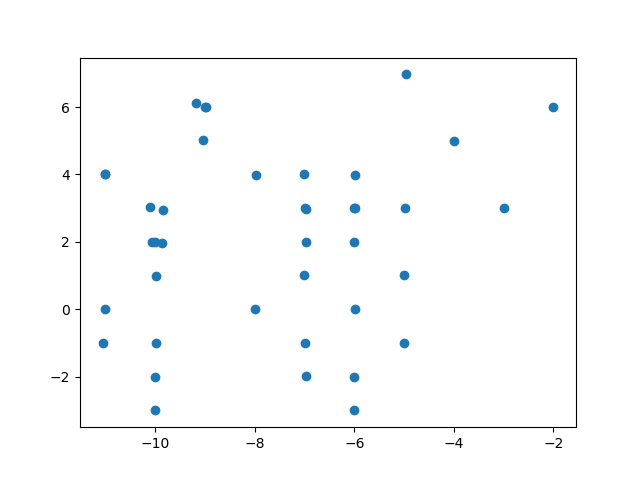

In [93]:
plt.scatter(da_peaks_strong.coords["h"].values, da_peaks_strong.coords["k"].values)

In [94]:
da_det_a

<scipp.DataArray>
Dimensions: Sizes[event:13981802, ]
Coordinates:
  ID_0                        int64  [dimensionless]  ()  1
  L1                        float64              [m]  ()  154.5
  L2                        float64              [m]  (event)  [1.60216, 1.64284, ..., 1.04165, 1.0282]
  Ltotal                    float64              [m]  (event)  [156.102, 156.143, ..., 155.542, 155.528]
  N_a                         int64  [dimensionless]  ()  128
  N_c                         int64  [dimensionless]  ()  32
  N_vs                        int64  [dimensionless]  ()  60
  Q_vec                     vector3           [1/Å]  (event)  [(-0.945066, 1.39493, 0.463345), (-0.987371, 1.41172, 0.486175), ..., (-3.10456, -0.133114, 1.86385), (-1.82739, 0.924361, 0.468856)]
* Q_vec_rot                 vector3           [1/Å]  (event)  [(-0.945066, 1.39493, 0.463345), (-0.987371, 1.41172, 0.486175), ..., (-3.10456, -0.133114, 1.86385), (-1.82739, 0.924361, 0.468856)]
  Qx                        float64           [1/Å]  (event)  [-0.945066, -0.987371, ..., -3.10456, -1.82739]
  Qy                        float64           [1/Å]  (event)  [1.39493, 1.41172, ..., -0.133114, 0.924361]
  Qz                        float64           [1/Å]  (event)  [0.463345, 0.486175, ..., 1.86385, 0.468856]
  a_b                       float64              [m]  ()  -0.722903
  a_t                       float64              [m]  ()  0.252863
  b_b                       float64              [m]  ()  -1.078
  b_t                       float64              [m]  ()  0.416545
  casette_delta_gamma       float64            [rad]  ()  0.018326
  casette_omega             float64            [rad]  ()  -0.158842
  delta_L                   float64              [m]  ()  0
  delta_t                   float64              [s]  ()  0.003
* event_gamma               float64            [rad]  (event)  [0.322101, 0.337996, ..., 1.08018, 0.407108]
* event_nu                  float64            [rad]  (event)  [-0.437103, -0.44272, ..., 0.0378011, -0.197673]
* event_peak                  int64  [dimensionless]  (event)  [0, 0, ..., 0, 0]
  event_position_global     vector3              [m]  (event)  [(0.425495, -1.35242, 155.874), (0.458241, -1.37799, 155.898), ..., (0.884121, -0.634832, 154.988), (0.365193, -0.876124, 155.423)]
  event_position_local      vector3              [m]  (event)  [(0.0874768, -0.678219, 1.44889), (0.113001, -0.703793, 1.48015), ..., (0.7599, 0.0393661, 0.711363), (0.145982, -0.201926, 0.997553)]
* event_position_local_mcstas  vector3              [m]  (event)  [(0.0871167, -0.679804, 1.45316), (0.113279, -0.703267, 1.47598), ..., (0.755576, 0.0383147, 0.706103), (0.14623, -0.202637, 0.989631)]
  gamma                     float64            [rad]  ()  0.261799
  ideal_sample_position     vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  incident_beam             vector3              [m]  ()  (0, 0, 154.5)
* norm_Q                    float64           [1/Å]  (event)  [1.74747, 1.79003, ..., 3.62353, 2.10087]
* peak                        int64  [dimensionless]  (event)  [0, 0, ..., 0, 0]
  position                  vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  r_d                       float64              [m]  ()  1
  r_vs                      float64              [m]  ()  0.53
  sample_chi                float64            [rad]  ()  0
  sample_offset             vector3              [m]  ()  (0, 0, 0)
  sample_omega              float64            [rad]  ()  0
  sample_phi                float64            [rad]  ()  0
  sample_position           vector3              [m]  ()  (-0.034, -0.674198, 154.497)
  sample_rotation         rotation3  [dimensionless]  ()  (1+0i+0j+0k)
  scattered_beam            vector3              [m]  (event)  [(0.459495, -0.678219, 1.37688), (0.492241, -0.703793, 1.40047), ..., (0.918121, 0.0393661, 0.490447), (0.399193, -0.201926, 0.925779)]
  source_position           vector3              [m]

In [105]:
da_det_a.coords["cell_a"] = unit_cell[0]
da_det_a.coords["cell_b"] = unit_cell[1]
da_det_a.coords["cell_c"] = unit_cell[2]
da_det_a.coords["cell_alpha"] = unit_cell[3]
da_det_a.coords["cell_beta"] = unit_cell[4]
da_det_a.coords["cell_gamma"] = unit_cell[5]
da_det_a.coords["euler_alpha"] = da_peaks.coords["euler_alpha"]
da_det_a.coords["euler_beta"] = da_peaks.coords["euler_beta"]
da_det_a.coords["euler_gamma"] = da_peaks.coords["euler_gamma"]
magic_scipp.remove_coords_in_da(da_det_a, "h", "k", "l", "h_reduced", "k_reduced", "l_reduced", "u_matrix", "ub_matrix", "b_matrix")
da_det_a = da_det_a.transform_coords(("h","k","l","h_reduced","k_reduced","l_reduced", "norm_Q"), graph={**magic_graphs.graph_hkl,**magic_graphs.graph_qvec})  

## Visualisation to see the quality of indexing

In [102]:
bin_h = sc.linspace(dim='h', start =-14,stop=-1,num=181,endpoint=True)
bin_k = sc.linspace(dim='k', start =-5,stop=8,num=341,endpoint=True)
bin_l = sc.linspace(dim='l', start =0,stop=10,num=341,endpoint=True)
# da_q_event_normalized.hist(h=bin_h).plot()
# da_q_event_normalized.hist(k=bin_k).plot()
# da_q_event_normalized.hist(l=bin_l).plot()

In [108]:
da_det_a.coords["h"] = da_det_a.coords["h"].copy()
da_det_a.coords["k"] = da_det_a.coords["k"].copy()
da_det_a.coords["l"] = da_det_a.coords["l"].copy()
da_det_a.coords["h_reduced"] = da_det_a.coords["h_reduced"].copy()
da_det_a.coords["k_reduced"] = da_det_a.coords["k_reduced"].copy()
da_det_a.coords["l_reduced"] = da_det_a.coords["l_reduced"].copy()

In [112]:
da_det_a.hist(h=bin_h, k=bin_k).plot(cmap='twilight')# norm="log"
da_det_a.hist(k=bin_k, l=bin_l).plot(cmap='twilight')# norm="log"
da_det_a.hist(h=bin_h, l=bin_l).plot(cmap='twilight')# norm="log"

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [113]:
bin_h_reduced = sc.linspace(dim='h_reduced', start =-0.5,stop=0.5,num=101,endpoint=True)
bin_k_reduced = sc.linspace(dim='k_reduced', start =-0.5,stop=0.5,num=101,endpoint=True)
bin_l_reduced = sc.linspace(dim='l_reduced', start =-0.5,stop=0.5,num=101,endpoint=True)

In [114]:
da_det_a.hist(h_reduced=bin_h_reduced, k_reduced=bin_k_reduced).plot(norm="log", cmap='twilight')

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [115]:
da_det_a.hist(k_reduced=bin_k_reduced, l_reduced=bin_l_reduced).plot(norm="log", cmap='twilight')

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [116]:
da_det_a.hist(l_reduced=bin_l_reduced, h_reduced=bin_h_reduced).plot(norm="log", cmap='twilight')

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [119]:
bin_q = sc.linspace(dim='norm_Q', start =1,stop=8,num=501,unit="1/Angstrom",endpoint=True)
da_det_a.hist(norm_Q=bin_q).plot()

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

## Correction on $\Delta t$, $\Delta L$, and sample offset

Correction is based on the events around strong peaks.


In [120]:
sc_flag = sc.zeros(dims=da_det_a.data.dims, shape = da_det_a.data.values.shape, dtype=bool) 
distance_treshold = sc.scalar(0.1, unit="1/Angstrom")
da_det_a = da_det_a.transform_coords(("Q_vec_rot",), graph=magic_graphs.graph_qvec)
qvec = da_det_a.coords["Q_vec_rot"]
N= da_peaks_strong.coords["Q_vec_rot"].size
i=0
for q in da_peaks_strong.coords["Q_vec_rot"]:
    print(f"{100*(i+1)/N:.2f}%", end="\r")
    i+=1
    flag = (sc.norm(qvec-q) < distance_treshold)
    sc_flag = sc.logical_or(sc_flag, flag)

da_det_a_strong = da_det_a[sc_flag]
da_det_a_strong

100.00%

<scipp.DataArray>
Dimensions: Sizes[event:486349, ]
Coordinates:
  ID_0                        int64  [dimensionless]  ()  1
  L1                        float64              [m]  ()  154.5
  L2                        float64              [m]  (event)  [1.6081, 1.04338, ..., 1.05741, 1.64196]
  Ltotal                    float64              [m]  (event)  [156.108, 155.543, ..., 155.557, 156.142]
  N_a                         int64  [dimensionless]  ()  128
  N_c                         int64  [dimensionless]  ()  32
  N_vs                        int64  [dimensionless]  ()  60
  Q_vec                     vector3           [1/Å]  (event)  [(-2.81421, 1.41059, 1.38969), (-3.27358, 0.43286, 0.936289), ..., (-2.83342, -0.0750206, 0.936368), (-4.13854, 2.74074, 3.20995)]
* Q_vec_rot                 vector3           [1/Å]  (event)  [(-2.81421, 1.41059, 1.38969), (-3.27358, 0.43286, 0.936289), ..., (-2.83342, -0.0750206, 0.936368), (-4.13854, 2.74074, 3.20995)]
  Qx                        float64           [1/Å]  (event)  [-2.81421, -3.27358, ..., -2.83342, -4.13854]
  Qy                        float64           [1/Å]  (event)  [1.41059, 0.43286, ..., -0.0750206, 2.74074]
  Qz                        float64           [1/Å]  (event)  [1.38969, 0.936289, ..., 0.936368, 3.20995]
  a_b                       float64              [m]  ()  -0.722903
  a_t                       float64              [m]  ()  0.252863
  b_b                       float64              [m]  ()  -1.078
  b_matrix                linear_transform3           [1/Å]  ()  ((0.0740643, -4.53513e-18, -4.53513e-18), (0, 0.0740643, -4.53513e-18), (0, 0, 0.0740643))
  b_t                       float64              [m]  ()  0.416545
  casette_delta_gamma       float64            [rad]  ()  0.018326
  casette_omega             float64            [rad]  ()  -0.158842
  cell_a                    float64             [Å]  ()  13.5018
  cell_alpha                float64            [deg]  ()  90
  cell_b                    float64             [Å]  ()  13.5018
  cell_beta                 float64            [deg]  ()  90
  cell_c                    float64             [Å]  ()  13.5018
  cell_gamma                float64            [deg]  ()  90
  delta_L                   float64              [m]  ()  0
  delta_t                   float64              [s]  ()  0.003
  euler_alpha               float64            [rad]  ()  -0.000432239
  euler_beta                float64            [rad]  ()  -0.00040884
  euler_gamma               float64            [rad]  ()  6.28356
* event_gamma               float64            [rad]  (event)  [0.775493, 0.548723, ..., 0.637972, 1.07601]
* event_nu                  float64            [rad]  (event)  [-0.337477, -0.0688609, ..., 0.0157676, -0.527696]
* event_peak                  int64  [dimensionless]  (event)  [0, 10, ..., 31, 20]
  event_position_global     vector3              [m]  (event)  [(1.02828, -1.20665, 155.581), (0.508934, -0.745989, 155.385), ..., (0.595681, -0.657526, 155.347), (1.21447, -1.501, 155.171)]
  event_position_local      vector3              [m]  (event)  [(0.745644, -0.532456, 1.32155), (0.294579, -0.0717912, 0.998352), ..., (0.388405, 0.0166721, 0.983351), (1.03158, -0.826798, 0.973788)]
* event_position_local_mcstas  vector3              [m]  (event)  [(0.742609, -0.525979, 1.31418), (0.294631, -0.0746063, 0.997609), ..., (0.389909, 0.0147623, 0.989219), (1.03676, -0.830645, 0.980138)]
  gamma                     float64            [rad]  ()  0.261799
* h                         float64  [dimensionless]  (event)  [-6.04747, -7.0341, ..., -6.08776, -8.89292]
* h_reduced                 float64  [dimensionless]  (event)  [-0.0474742, -0.0340967, ..., -0.087763, 0.10708]
  hkl_vec                   vector3  [dimensionless]  (event)  [(-6.04747, 3.0297, 2.9876), (-7.0341, 0.927884, 2.01449), ..., (-6.08776, -0.163079, 2.01469), (-8.89292, 5.88828, 6.8992)]
  ideal_sample_position     vector3              [m]  ()  (-0.034, -

In [121]:
da_det_a_strong = da_det_a_strong.transform_coords(("h_reduced", "k_reduced", "l_reduced"), graph={**magic_graphs.graph_qvec, **magic_graphs.graph_hkl})
# da_q_event_normalized_strong.hist(h_reduced=bin_h_reduced, k_reduced=bin_k_reduced).plot(cmap='twilight',)#norm="log", 

In [ ]:
# da_q_event_normalized_strong.hist(k_reduced=bin_k_reduced, l_reduced=bin_l_reduced).plot(cmap='twilight',)# ,norm="log" 

In [ ]:
# da_q_event_normalized_strong.hist(l_reduced=bin_l_reduced, h_reduced=bin_h_reduced).plot(cmap='twilight')# norm="log", 

In [122]:
get_ub.optimize_delta_t_delta_l(da_det_a_strong)

Original chi_sq 0.0034372396323184675
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.003298428352592824
        x: [ 2.303e-03 -1.927e-02  1.372e+01 -4.824e-04  5.278e-05
             6.284e+00]
      nit: 17
      jac: [ 5.398e-07  2.782e-08  2.328e-09 -1.226e-06 -2.272e-07
            -6.106e-07]
 hess_inv: [[ 2.220e-03  5.808e-02 ...  2.206e-05 -4.946e-05]
            [ 5.808e-02  2.538e+00 ...  5.903e-04 -1.313e-03]
            ...
            [ 2.206e-05  5.903e-04 ...  2.705e-02 -2.919e-02]
            [-4.946e-05 -1.313e-03 ... -2.919e-02  1.542e-01]]
     nfev: 161
     njev: 23


In [124]:
da_det_a_strong = da_det_a_strong.transform_coords(("h_reduced", "k_reduced", "l_reduced"), graph={**magic_graphs.graph_qvec, **magic_graphs.graph_hkl})



In [ ]:
# da_q_event_normalized_strong.hist(h_reduced=bin_h_reduced, k_reduced=bin_k_reduced).plot(cmap='twilight',)#norm="log", 

In [ ]:
# da_q_event_normalized_strong.hist(k_reduced=bin_k_reduced, l_reduced=bin_l_reduced).plot(cmap='twilight',)#norm="log", 

In [ ]:
# da_q_event_normalized_strong.hist(l_reduced=bin_l_reduced, h_reduced=bin_h_reduced).plot(cmap='twilight',)#norm="log", 

In [125]:
da_det_a.coords["delta_t"] = da_det_a_strong.coords["delta_t"]
da_det_a.coords["delta_L"] = da_det_a_strong.coords["delta_L"]
da_det_a.coords["cell_a"] = da_det_a_strong.coords["cell_a"]
da_det_a.coords["cell_b"] = da_det_a_strong.coords["cell_b"]
da_det_a.coords["cell_c"] = da_det_a_strong.coords["cell_c"]
da_det_a.coords["cell_alpha"] = da_det_a_strong.coords["cell_alpha"]
da_det_a.coords["cell_beta"] = da_det_a_strong.coords["cell_beta"]
da_det_a.coords["cell_gamma"] = da_det_a_strong.coords["cell_gamma"]
da_det_a.coords["euler_alpha"] = da_det_a_strong.coords["euler_alpha"]
da_det_a.coords["euler_beta"] = da_det_a_strong.coords["euler_beta"]
da_det_a.coords["euler_gamma"] = da_det_a_strong.coords["euler_gamma"]
magic_scipp.remove_coords_in_da(da_det_a, "h", "k", "l", "h_reduced", "k_reduced", "l_reduced", "hkl_vec","Q_vec_rot","Q_vec","Qx","Qy","Qz","wavelength", "tof", "Ltotal", "Q", "u_matrix", "b_matrix", "ub_matrix")
da_det_a = da_det_a.transform_coords(("h_reduced", "k_reduced", "l_reduced"), graph={**magic_graphs.graph_qvec, **magic_graphs.graph_hkl})
da_det_a

<scipp.DataArray>
Dimensions: Sizes[event:13981802, ]
Coordinates:
  ID_0                        int64  [dimensionless]  ()  1
  L1                        float64              [m]  ()  154.5
  L2                        float64              [m]  (event)  [1.60216, 1.64284, ..., 1.04165, 1.0282]
  Ltotal                    float64              [m]  (event)  [156.121, 156.162, ..., 155.561, 155.547]
  N_a                         int64  [dimensionless]  ()  128
  N_c                         int64  [dimensionless]  ()  32
  N_vs                        int64  [dimensionless]  ()  60
  Q_vec                     vector3           [1/Å]  (event)  [(-0.936511, 1.3823, 0.45915), (-0.978435, 1.39894, 0.481774), ..., (-3.0744, -0.131821, 1.84575), (-1.80367, 0.912363, 0.462771)]
  Q_vec_rot                 vector3           [1/Å]  (event)  [(-0.936511, 1.3823, 0.45915), (-0.978435, 1.39894, 0.481774), ..., (-3.0744, -0.131821, 1.84575), (-1.80367, 0.912363, 0.462771)]
  Qx                        float64           [1/Å]  (event)  [-0.936511, -0.978435, ..., -3.0744, -1.80367]
  Qy                        float64           [1/Å]  (event)  [1.3823, 1.39894, ..., -0.131821, 0.912363]
  Qz                        float64           [1/Å]  (event)  [0.45915, 0.481774, ..., 1.84575, 0.462771]
  a_b                       float64              [m]  ()  -0.722903
  a_t                       float64              [m]  ()  0.252863
  b_b                       float64              [m]  ()  -1.078
  b_matrix                linear_transform3           [1/Å]  ()  ((0.072866, -4.46175e-18, -4.46175e-18), (0, 0.072866, -4.46175e-18), (0, 0, 0.072866))
  b_t                       float64              [m]  ()  0.416545
  casette_delta_gamma       float64            [rad]  ()  0.018326
  casette_omega             float64            [rad]  ()  -0.158842
  cell_a                    float64             [Å]  ()  13.7238
  cell_alpha                float64            [deg]  ()  90
  cell_b                    float64             [Å]  ()  13.7238
  cell_beta                 float64            [deg]  ()  90
  cell_c                    float64             [Å]  ()  13.7238
  cell_gamma                float64            [deg]  ()  90
  delta_L                   float64              [m]  ()  -0.0192738
  delta_t                   float64              [s]  ()  0.00230328
  euler_alpha               float64            [rad]  ()  -0.000482436
  euler_beta                float64            [rad]  ()  5.27826e-05
  euler_gamma               float64            [rad]  ()  6.28365
* event_gamma               float64            [rad]  (event)  [0.322101, 0.337996, ..., 1.08018, 0.407108]
* event_nu                  float64            [rad]  (event)  [-0.437103, -0.44272, ..., 0.0378011, -0.197673]
* event_peak                  int64  [dimensionless]  (event)  [0, 0, ..., 0, 0]
  event_position_global     vector3              [m]  (event)  [(0.425495, -1.35242, 155.874), (0.458241, -1.37799, 155.898), ..., (0.884121, -0.634832, 154.988), (0.365193, -0.876124, 155.423)]
  event_position_local      vector3              [m]  (event)  [(0.0874768, -0.678219, 1.44889), (0.113001, -0.703793, 1.48015), ..., (0.7599, 0.0393661, 0.711363), (0.145982, -0.201926, 0.997553)]
* event_position_local_mcstas  vector3              [m]  (event)  [(0.0871167, -0.679804, 1.45316), (0.113279, -0.703267, 1.47598), ..., (0.755576, 0.0383147, 0.706103), (0.14623, -0.202637, 0.989631)]
  gamma                     float64            [rad]  ()  0.261799
  h                         float64  [dimensionless]  (event)  [-2.04705, -2.13864, ..., -6.71523, -3.94063]
* h_reduced                 float64  [dimensionless]  (event)  [-0.04705, -0.138641, ..., 0.284769, 0.0593727]
  hkl_vec                   vector3  [dimensionless]  (event)  [(-2.04705, 3.01871, 1.00138), (-2.13864, 3.05504, 1.05078), ..., (-6.71523, -0.289305, 4.03129), (-3.94063, 1.99136, 1.00966)]
  ideal_sample_position     vector3              [m]  () 

In [126]:
da_det_a.hist(h_reduced=bin_h_reduced, k_reduced=bin_k_reduced).plot(norm="log", cmap='twilight',)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [127]:
da_det_a.hist(k_reduced=bin_k_reduced, l_reduced=bin_l_reduced).plot(norm="log", cmap='twilight',)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [128]:
da_det_a.hist(l_reduced=bin_l_reduced, h_reduced=bin_h_reduced).plot(norm="log", cmap='twilight',)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

## Shape of the diffraction peak
...

# Peak integration

Model Fsq (used in McStas simulation)


In [ ]:
# def load_fsq(f_name:str):
#     with open(f_name, 'r') as fid:
#         l_content = fid.readlines()
#     l_content = [hh for hh in l_content if not hh.startswith("#")]
#     l_hkl, l_fsq = [], []
#     for line in l_content:
#         l_hh = line.strip().split()
#         l_hkl.append((int(l_hh[0]), int(l_hh[1]), int(l_hh[2])))
#         l_fsq.append(l_hh[-1])
#     np_hkl = numpy.array(l_hkl, dtype=int).transpose()
#     np_fsq = numpy.array(l_fsq, dtype = float)
#     return np_hkl, np_fsq
# f_name_fsq = "C60_tetra.hkl"
# np_hkl_model, np_fsq_model = load_fsq(f_name_fsq)

Naive integration

In [129]:
import importlib
importlib.reload(integrate_peaks)

<module 'integrate_peaks' from '/Users/iuriikibalin/Repositories/magic-notebooks/integrate_peaks.py'>

<scipp.Variable> (event: 13981802)       bool        <no unit>  [False, False, ..., False, False]

In [137]:
da = da_det_a
da.masks['detector_border'] = sc.zeros(dims=da_det_a.dims, shape= da_det_a.shape, dtype=bool)
scale = 33.6992238296537
integration_box = [0.5, 0.5, 0.5]
np_hkl_int, np_fsq_exp, np_wavelength, np_tth = integrate_peaks.naive_integration(da, integration_box, scale=scale)

Progress: 100.00

Form CIF object for experiment

In [ ]:

plopp.scatter3d(da_q_event_normalized, pos='hkl_vec', cbar=True, size=0.0001, opacity=0.5)

# Output

## CrysPY

In [142]:
import cryspy

In [143]:
l_item = []
for hkl, fsq, wavelength in zip(np_hkl_int.T, np_fsq_exp, np_wavelength):
    sfsq = 0.01 * fsq
    l_item.append(
        cryspy.DiffrnRefln(index_h=hkl[0], index_k=hkl[1], index_l=hkl[2], intensity=fsq, intensity_sigma=sfsq, wavelength=wavelength[0])
    )
l_diffrn_refln = cryspy.DiffrnReflnL()
l_diffrn_refln.items = l_item
np_ub = da_q_event_normalized.coords['ub_matrix'].values
difrn_orient_matrix = cryspy.DiffrnOrientMatrix(
    ub_11 = np_ub[0,0],
    ub_12 = np_ub[0,1],
    ub_13 = np_ub[0,2],
    ub_21 = np_ub[1,0],
    ub_22 = np_ub[1,1],
    ub_23 = np_ub[1,2],
    ub_31 = np_ub[2,0],
    ub_32 = np_ub[2,1],
    ub_33 = np_ub[2,2],
)
phase = cryspy.Phase(label="c60", scale=1.)
extinction = cryspy.Extinction(model="gauss", mosaicity=0., radius=0.)
setup = cryspy.Setup(field=0.)
difrn_orient_matrix.form_object()
exp_sc = cryspy.Diffrn(data_name = "exp1")
exp_sc.add_items([l_diffrn_refln, difrn_orient_matrix, phase, extinction, setup])

In [144]:
s_cif_c60 = """data_c60

_cell_length_a 14.152000
_cell_length_b 14.152000
_cell_length_c 14.152000
_cell_angle_alpha 90.000000
_cell_angle_beta 90.000000
_cell_angle_gamma 90.000000

_space_group_name_H-M_alt "P a -3"
_space_group_IT_coordinate_system_code 1

loop_
_atom_site_label
_atom_site_type_symbol
_atom_site_fract_x
_atom_site_fract_y
_atom_site_fract_z
_atom_site_occupancy
_atom_site_adp_type
_atom_site_U_iso_or_equiv
_atom_site_B_iso_or_equiv
_atom_site_multiplicity
_atom_site_Wyckoff_symbol
  C11   C   0.229400   0.967500   0.101000   1.0   Biso   0.0038   0.0   24   d
  C12   C   0.246700   0.946000   0.006100   1.0   Biso   0.0038   0.0   24   d
  C21   C   0.208100   0.064600   0.128900   1.0   Biso   0.0038   0.0   24   d
  C22   C   0.206600   0.859900   0.964000   1.0   Biso   0.0038   0.0   24   d
  C23   C   0.171000   0.903700   0.159000   1.0   Biso   0.0038   0.0   24   d
  C34   C   0.223600   0.112200   0.962900   1.0   Biso   0.0038   0.0   24   d
  C24   C   0.243900   0.019200   0.936400   1.0   Biso   0.0038   0.0   24   d
  C31   C   0.205300   0.134900   0.061600   1.0   Biso   0.0038   0.0   24   d
  C32   C   0.150300   0.798300   0.020200   1.0   Biso   0.0038   0.0   24   d
  C33   C   0.132300   0.820700   0.118600   1.0   Biso   0.0038   0.0   24   d

"""
rcif_obj = cryspy.str_to_globaln(s_cif_c60)
rcif_obj.add_items([exp_sc,])
rcif_obj

Attribute,Note
.crystal_c60,The block ‘Crystal’ describes the crystal structure.
.crystal_c60.atom_site,AtomSite describes position of atom in unit cell together with type of atomic vibations.
.crystal_c60.cell,Cell
.crystal_c60.space_group,SpaceGroup defines the crystal space group.
.diffrn_exp1,Single diffraction experiment with polarized neutrons.
.diffrn_exp1.diffrn_orient_matrix,UB-matrix desription.
.diffrn_exp1.diffrn_refln,Flip ratios measured in the single diffraction experiment.
.diffrn_exp1.extinction,Extinction.
.diffrn_exp1.phase,Phase class.
.diffrn_exp1.setup,Experimental diffraction setup (constant wavelength).


[(<Figure size 640x480 with 1 Axes>,
  <Axes: title={'center': 'exp1 - Intensity, $\\chi^2/n=$16353241551979340341347721772480897945177411134702738583109890875656172667404288.00  $RF^2=$2199.7%'}, xlabel='Intensity (model)', ylabel='Intensity (experiment)'>)]

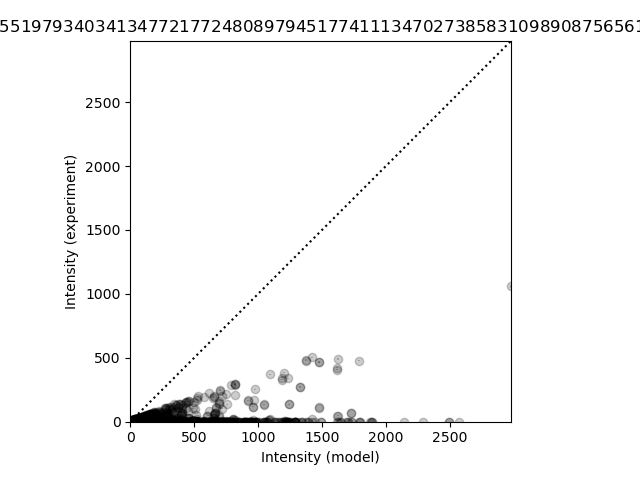

In [145]:
cryspy.rhochi_no_refinement(rcif_obj)
rcif_obj.plots()

*********************************************
Rietveld refinement by CrysPy (module RhoChi)
*********************************************

Derivatives are calculated numerically.
Started chi_sq per number of points is 16353241551979340341347721772480897945177411134702738583109890875656172667404288.00.         
Number of fitting parameters 1
 - ('diffrn_exp1', 'phase_scale', (np.int64(0),))  1.00000

Optimization is done.                                      
Optimal chi_sq per n is 900387569855959692869007680452094703333580014967473309812260864.00
Optimal parameters:
 - scale -0.00000
Errors are estimating by numerical derivatives.


[(<Figure size 640x480 with 1 Axes>,
  <Axes: title={'center': 'exp1 - Intensity, $\\chi^2/n=$10000.00  $RF^2=$100.0%'}, xlabel='Intensity (model)', ylabel='Intensity (experiment)'>)]

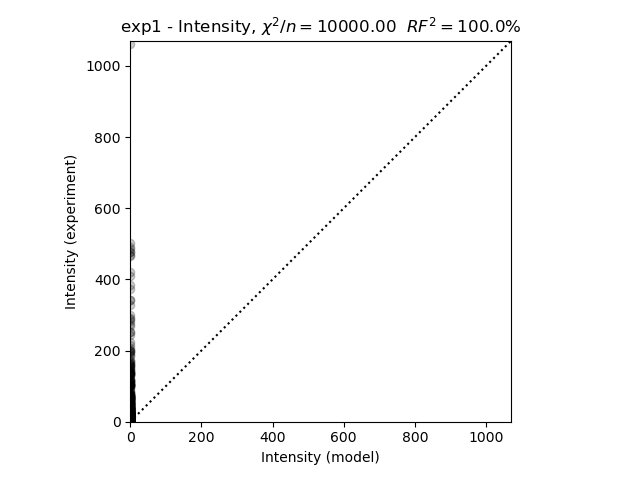

In [146]:
rcif_obj.diffrn_exp1.phase.scale_refinement = True
cryspy.rhochi_rietveld_refinement(rcif_obj)
rcif_obj.plots()

In [ ]:
with open("c60.rcif", "w") as fid:
    fid.write(rcif_obj.to_cif())

# Output
Export results in formats compatible with refinement tools
## EasyDiffraction
...
## FullProf 
...
## Mag2Pol
...


In [ ]:
https://scipp.github.io/user-guide/groupby.html

Probably use it for integration: asign area of detectors for indexation and integrate further

In [ ]:
# Synthetic example with 3 peaks
rng = numpy.random.default_rng(0)

centers = numpy.array([
    [0.2, 0.1, 0.0],
    [0.8, -0.2, 0.3],
    [-0.4, 0.5, -0.1]
])

q_events = []
weights = []

for c in centers:
    pts = c + 0.03 * rng.standard_normal((800, 3))
    q_events.append(pts)
    weights.append(rng.uniform(0.5, 1.5, size=800))

q_events = numpy.vstack(q_events)
weights = numpy.concatenate(weights)

peaks, intensities = find_multiple_peaks(q_events, weights, max_peaks=3)

print("Detected peaks:\n", peaks)
print("Intensities:\n", intensities)


In [ ]:
Detected peaks:
 [[-0.40223781  0.50135126 -0.09777805]
 [ 0.19728945  0.10152996 -0.00128652]]
Intensities:
 [795.38879818 794.77672387]

In [ ]:
import numpy as np
from scipy.spatial import KDTree

def reduce_kspace_events(
    k_points,
    weights,
    target_count=None,
    distance_threshold=None,
):
    """
    Reduce weighted events in k-space by parallel merging of nearest neighbors.

    Parameters
    ----------
    k_points : (N, d) array
        Event coordinates in k-space.
    weights : (N,) array
        Event weights.
    target_count : int or None
        Stop when number of events <= target_count.
    distance_threshold : float or None
        Stop when all nearest-neighbor distances exceed this value.

    Returns
    -------
    k_points : (M, d) array
        Reduced coordinates.
    weights : (M,) array
        Reduced weights.
    """

    k_list = [np.array(k) for k in k_points]
    w_list = [float(w) for w in weights]

    while True:

        N = len(k_list)
        if target_count is not None and N <= target_count:
            break

        # Build KDTree
        tree = KDTree(np.vstack(k_list))

        # Query nearest neighbor for each point
        dists, idxs = tree.query(np.vstack(k_list), k=2)
        nn_dist = dists[:, 1]
        nn_idx = idxs[:, 1]

        # Check distance threshold stopping condition
        if distance_threshold is not None:
            if np.all(nn_dist > distance_threshold):
                break

        # Build list of candidate pairs (i, j, dist)
        pairs = [(i, nn_idx[i], nn_dist[i]) for i in range(N)]
        # Sort by distance
        pairs.sort(key=lambda x: x[2])

        merged = set()
        new_k = []
        new_w = []

        # Parallel merging: take smallest non-overlapping pairs
        for i, j, d in pairs:
            if i in merged or j in merged:
                continue
            if distance_threshold is not None and d > distance_threshold:
                break

            # Merge i and j
            wi, wj = w_list[i], w_list[j]
            ki, kj = k_list[i], k_list[j]

            w_new = wi + wj
            k_new = (wi * ki + wj * kj) / w_new

            new_k.append(k_new)
            new_w.append(w_new)

            merged.add(i)
            merged.add(j)

        # Add all unmerged points
        for idx in range(N):
            if idx not in merged:
                new_k.append(k_list[idx])
                new_w.append(w_list[idx])

        k_list = new_k
        w_list = new_w

        # If no merges happened, stop
        if len(merged) == 0:
            break

    return np.vstack(k_list), np.array(w_list)




In [ ]:

# Example: 2000 events in 3D
N = 2000000
k = np.random.randn(N, 1)
w = np.random.rand(N)

k_red, w_red = reduce_kspace_events(
    k, w,
    target_count=300,
    distance_threshold=0.05
)

print(k_red.shape, w_red.shape)

In [ ]:
k_red.min(), k_red.max()

	◦ max_seeds: e.g. 10^3–10^4 seeds instead of all events.
	◦ radius_factor: trade off accuracy vs speed (smaller → fewer neighbors).
	◦ Region cuts in Q before building the tree.

In [ ]:
k_red, w_red = reduce_kspace_events(
    k_red, w_red,
    target_count=300,
    distance_threshold=0.05
)

print(k_red.shape, w_red.shape)

In [ ]:
peaks, intensities = find_multiple_peaks_accel(np_qxyz, np_weight, max_peaks=30)
print("Detected peaks:\n", peaks)
print("Intensities:\n", intensities)